## **Diabetes Risk Classification**

The goal of this analysis is to evaluate different classification models (Decision Tree, K-Nearest Neighbors, Naive Bayes, Support Vector Machine, and Artificial Neural Network) for their ability to predict diabetes risk categories using a range of health and lifestyle factors. The dataset was obtained from Kaggle and simulates realistic patterns associated with diabetes development. Model performance was compared using classification metrics, confusion matrices, and feature importance analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.inspection import permutation_importance

In [2]:
# Load dataset
data = pd.read_csv("data/diabetes_risk_dataset.csv")

### **Data Preprocessing**

Irrelevant features were removed, including Patient_ID (unique identifier) and diabetes_risk_score (a continuous version of the target variable). Categorical features and the target variable were encoded into numerical values. The dataset was then split into training (80%) and test (20%) sets. Feature scaling using StandardScaler was applied to a copy of the data for distance-based models such as KNN, SVM, and Neural Networks.

In [3]:
data = data.drop(columns = ["Patient_ID", "diabetes_risk_score"])

data["gender"] = data["gender"].map({"Male": 0, "Female": 1})
data["family_history_diabetes"] = data["family_history_diabetes"].map(
    {"No": 0, "Yes": 1})

data["physical_activity_level"] = data["physical_activity_level"].map(
    {"Low": 0, "Moderate": 1, "High": 2})

data["diabetes_risk_category"] = data["diabetes_risk_category"].map(
    {"Low Risk": 0, "Prediabetes": 1, "High Risk": 2})

X = data.drop(columns = "diabetes_risk_category")
Y = data["diabetes_risk_category"]

# Split training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    train_size = 0.80,
                                                    stratify = Y,
                                                    random_state = 11)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to a pandas DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, 
                 columns=X_train.columns, index = X_train.index) 
X_test_scaled = pd.DataFrame(X_test_scaled, 
                columns=X_train.columns, index = X_test.index ) 

### **Classification Models**
#### Decision Tree

 A decision tree classifier was trained using the Gini impurity criterion. The maximum depth was tuned by evaluating models with depths from 1 to 50 and comparing their training and test accuracies. A maximum depth of 8 was selected to balance model performance and avoid overfitting.

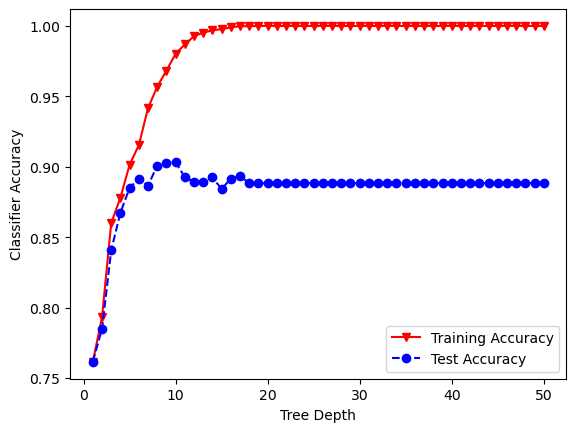

In [4]:
#Tune max_depth 
depths = []
train_accuracy = []
test_accuracy = []
for k in range(1, 51):
    decisiontree = tree.DecisionTreeClassifier(criterion = "gini", 
    max_depth = k, random_state = 11)
    decisiontree.fit(X_train, Y_train)
    train_predict = decisiontree.predict(X_train)
    test_predict = decisiontree.predict(X_test)
    accuracy_train = accuracy_score(Y_train, train_predict)
    accuracy_test = accuracy_score(Y_test, test_predict)
    depths.append(k)
    train_accuracy.append(accuracy_train)
    test_accuracy.append(accuracy_test)

# Plot of training and test accuracies vs the tree depths  
plt.plot(depths, train_accuracy,'rv-', depths, test_accuracy,'bo--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Tree Depth')
plt.ylabel('Classifier Accuracy')
plt.show()

**************** Decision tree model ****************

              precision    recall  f1-score   support

    Low Risk       0.95      0.93      0.94       520
 Prediabetes       0.74      0.77      0.75       231
   High Risk       0.94      0.93      0.93       449

    accuracy                           0.90      1200
   macro avg       0.87      0.88      0.88      1200
weighted avg       0.90      0.90      0.90      1200



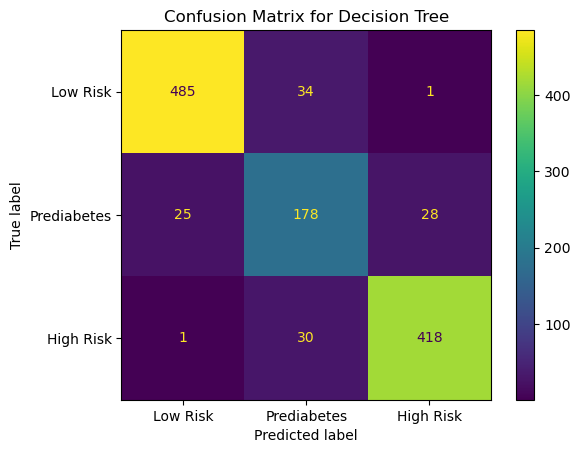

                       Feature  Importance
2                          bmi    0.638631
4        fasting_glucose_level    0.189838
14     family_history_diabetes    0.033387
0                          age    0.032014
6                  HbA1c_level    0.030449
3               blood_pressure    0.020208
13                stress_level    0.011614
10        daily_calorie_intake    0.010108
15      waist_circumference_cm    0.008585
11  sugar_intake_grams_per_day    0.005906
5                insulin_level    0.005494
12                 sleep_hours    0.005438
8          triglycerides_level    0.004317
7            cholesterol_level    0.002765
9      physical_activity_level    0.000632
1                       gender    0.000613


In [5]:
decisiontree = tree.DecisionTreeClassifier(criterion = "gini", 
                                           max_depth = 8, 
                                           random_state = 11)
# Train the decision tree
decisiontree.fit(X_train, Y_train)
# Classify test records
tree_test_predict = decisiontree.predict(X_test)

# Classification metrics 
print("**************** Decision tree model ****************\n")
print(classification_report(Y_test, tree_test_predict, 
      target_names = ["Low Risk", "Prediabetes", "High Risk"]))

# Create and display confusion matrix
matrix = confusion_matrix(Y_test, tree_test_predict)
display = ConfusionMatrixDisplay(confusion_matrix = matrix,
          display_labels = ["Low Risk", "Prediabetes", "High Risk"])
display.plot()
plt.title("Confusion Matrix for Decision Tree")
plt.show()

# Feature importance analysis
importance_scores = decisiontree.feature_importances_
feature_names = X_train.columns
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False)
print(importance)

The Decision Tree model achieved an accuracy of 90% on the test set. The model performed well in identifying the Low Risk and High Risk categories, but showed lower performance for the Prediabetes category. Feature importance analysis indicated that bmi was the most influential attribute by far, followed by fasting_glucose_level and family_history_diabetes.

#### K-Nearest Neighbors

A KNN classifier was trained using the scikit-learn implementation. The optimal number of neighbors (k) was determined by evaluating values from 1 to 50 and comparing test accuracy. The value of k that achieved the highest test accuracy was selected for the final model.

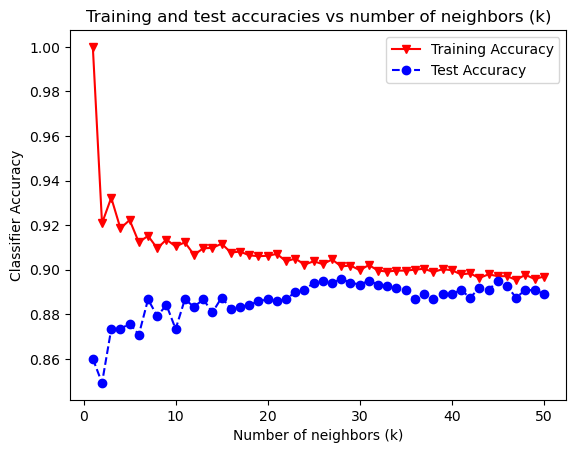

In [6]:
# Find the optimal value of k
k_values = range(1, 51)
train_accuracy_knn = []
test_accuracy_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    train_predict = knn.predict(X_train_scaled)
    test_predict = knn.predict(X_test_scaled)
    accuracy_train = accuracy_score(Y_train, train_predict)
    accuracy_test = accuracy_score(Y_test, test_predict)
    train_accuracy_knn.append(accuracy_train)
    test_accuracy_knn.append(accuracy_test)

# Plot of training and test accuracies vs the tree depths  
plt.plot(k_values, train_accuracy_knn,'rv-', k_values, test_accuracy_knn,'bo--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.title("Training and test accuracies vs number of neighbors (k)")
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Classifier Accuracy')
plt.show()

best_k = k_values[test_accuracy_knn.index(max(test_accuracy_knn))]


**************** KNN  model ****************

              precision    recall  f1-score   support

    Low Risk       0.92      0.95      0.93       520
 Prediabetes       0.74      0.70      0.72       231
   High Risk       0.94      0.94      0.94       449

    accuracy                           0.90      1200
   macro avg       0.87      0.86      0.86      1200
weighted avg       0.89      0.90      0.89      1200



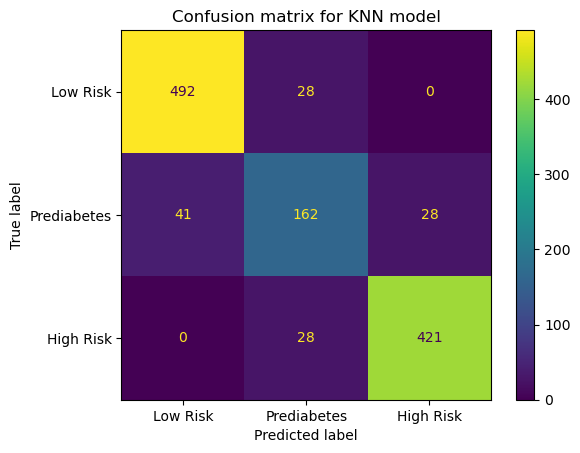

                       Feature  Importance
15      waist_circumference_cm    0.060333
2                          bmi    0.054000
14     family_history_diabetes    0.035750
10        daily_calorie_intake    0.035417
9      physical_activity_level    0.034750
4        fasting_glucose_level    0.033667
6                  HbA1c_level    0.030167
0                          age    0.029667
3               blood_pressure    0.023250
7            cholesterol_level    0.018083
8          triglycerides_level    0.016167
5                insulin_level    0.014667
13                stress_level    0.010083
11  sugar_intake_grams_per_day    0.008917
1                       gender    0.008250
12                 sleep_hours    0.003833


In [7]:
# Train the KNN model with the best value of k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, Y_train)

# Predict the class labels
y_pred_knn = knn_model.predict(X_test_scaled)

# Classification metrics 
print("\n**************** KNN  model ****************\n")
print(classification_report(Y_test, y_pred_knn, 
      target_names = ["Low Risk", "Prediabetes", "High Risk"]))

# Create and display confusion matrix
conf_matrix_knn = confusion_matrix(Y_test, y_pred_knn)
conf_matrix_disp_knn = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=['Low Risk', 'Prediabetes', 'High Risk'])
conf_matrix_disp_knn.plot()
plt.title("Confusion matrix for KNN model")
plt.show()

# Analysis using permutation feature importance
result_knn = permutation_importance(knn_model, X_test_scaled, Y_test, 
    n_repeats = 10, random_state = 11, scoring = "accuracy")
importance_knn = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result_knn.importances_mean
}).sort_values("Importance", ascending=False)
print(importance_knn)

The KNN model achieved an accuracy of 90% on the test set. The classifier strongly identified the Low Risk and High Risk categories. Permutation feature analysis indicated that the most influential attributes were waist_circumference_cm and bmi, followed by family_history_diabetes and daily_calorie_intake.

#### Naive Bayes

A Gaussian Naive Bayes classifier was trained using default parameters. Since the model is not sensitive to feature scaling and requires minimal hyperparameter tuning, it was applied directly to the non-scaled dataset.

**************** Naive Bayes model ****************

              precision    recall  f1-score   support

    Low Risk       0.96      0.88      0.92       520
 Prediabetes       0.56      0.78      0.66       231
   High Risk       0.93      0.83      0.88       449

    accuracy                           0.84      1200
   macro avg       0.82      0.83      0.82      1200
weighted avg       0.87      0.84      0.85      1200



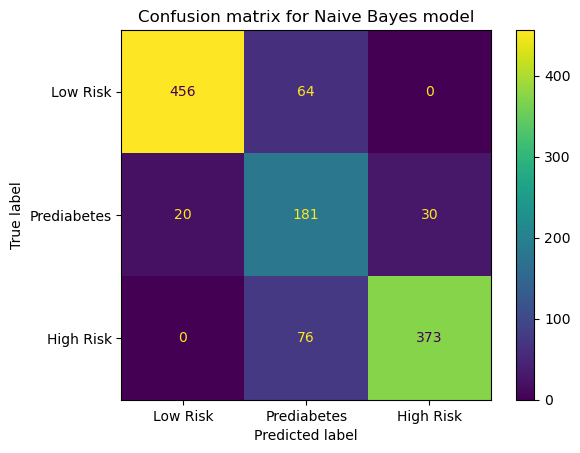

                       Feature  Importance
9      physical_activity_level    0.056667
4        fasting_glucose_level    0.047583
2                          bmi    0.045250
15      waist_circumference_cm    0.041500
6                  HbA1c_level    0.030750
10        daily_calorie_intake    0.016917
3               blood_pressure    0.016083
7            cholesterol_level    0.011083
8          triglycerides_level    0.008417
11  sugar_intake_grams_per_day    0.004167
0                          age    0.003167
14     family_history_diabetes    0.001083
1                       gender    0.000000
5                insulin_level   -0.000083
13                stress_level   -0.001000
12                 sleep_hours   -0.002000


In [8]:
nb_model = GaussianNB()

# Train the Naive Bayes model and predict the class labels
nb_model.fit(X_train, Y_train)
y_pred_nb = nb_model.predict(X_test)

# Classification metrics
print("**************** Naive Bayes model ****************\n")
print(classification_report(Y_test, y_pred_nb, 
      target_names = ["Low Risk", "Prediabetes", "High Risk"]))

# Create and display a confusion matrix
conf_matrix_nb = confusion_matrix(Y_test, y_pred_nb)
conf_matrix_disp_nb = ConfusionMatrixDisplay(conf_matrix_nb, display_labels=['Low Risk', 'Prediabetes', 'High Risk'])
conf_matrix_disp_nb.plot()
plt.title("Confusion matrix for Naive Bayes model")
plt.show()

# Analysis using permutation feature importance
result_nb = permutation_importance(nb_model, X_test, Y_test, 
    n_repeats = 10, random_state = 11, scoring = "accuracy")
importance_nb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result_nb.importances_mean
}).sort_values("Importance", ascending=False)
print(importance_nb)

The Naive Bayes model achieved an accuracy of 84% on the test set. It performed best for the Low Risk category, but showed weaker performance for Prediabetes, primarily due to low precision. Permutation feature importance indicated that physical_activity_level, fasting_glucose_level, bmi, and waist_circumference_cm were the most influential features.

#### Support Vector Machine

A Support Vector Machine classifier was trained using the radial basis function (RBF) kernel. As a distance-based model, feature scaling was applied to the dataset prior to training and evaluation.

**************** SVM model ****************

              precision    recall  f1-score   support

    Low Risk       0.96      0.96      0.96       520
 Prediabetes       0.83      0.84      0.84       231
   High Risk       0.97      0.96      0.96       449

    accuracy                           0.94      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.94      0.94      0.94      1200



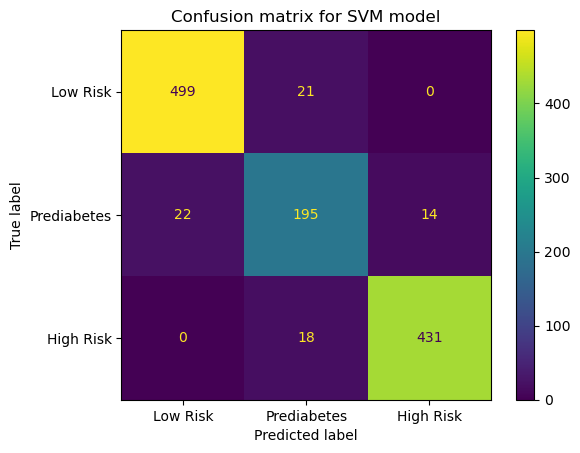

                       Feature  Importance
15      waist_circumference_cm    0.158500
2                          bmi    0.129333
4        fasting_glucose_level    0.128000
0                          age    0.051417
6                  HbA1c_level    0.045333
14     family_history_diabetes    0.038667
9      physical_activity_level    0.030583
1                       gender    0.024917
10        daily_calorie_intake    0.004417
8          triglycerides_level    0.001917
5                insulin_level    0.000917
12                 sleep_hours    0.000833
3               blood_pressure    0.000583
11  sugar_intake_grams_per_day   -0.001333
7            cholesterol_level   -0.001667
13                stress_level   -0.004250


In [9]:
svm_model = SVC(kernel='rbf')
# Train the SVM model and predict the class labels
svm_model.fit(X_train_scaled, Y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Classification metrics
print("**************** SVM model ****************\n")
print(classification_report(Y_test, y_pred_svm, 
      target_names = ["Low Risk", "Prediabetes", "High Risk"]))

# Create and display a confusion matrix
conf_matrix_svm = confusion_matrix(Y_test, y_pred_svm)
conf_matrix_disp_svm = ConfusionMatrixDisplay(conf_matrix_svm, display_labels=['Low Risk', 'Prediabetes', 'High Risk'])
conf_matrix_disp_svm.plot()
plt.title("Confusion matrix for SVM model")
plt.show()

# Analysis using permutation feature importance
result_svm = permutation_importance(svm_model, X_test_scaled, Y_test, 
    n_repeats = 10, random_state = 11, scoring = "accuracy")
importance_svm = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result_svm.importances_mean
}).sort_values("Importance", ascending=False)
print(importance_svm)


The SVM model achieved an accuracy of 94% on the test set. It performed strongly across all categories, with F1-scores of 0.96 for Low Risk, 0.84 for Prediabetes, and 0.96 for High Risk. Feature importance analysis showed that waist_circumference_cm, bmi, and fasting_glucose_level were the most influential variables, followed by age.

#### Artificial Neural Network

An Artificial Neural Network was implemented using a Multi-Layer Perceptron (MLP) classifier with a single hidden layer and the ReLU activation function. The number of neurons in the hidden layer was tuned by evaluating models with 5, 10, 20, 30, and 50 neurons and comparing training and test accuracy. A hidden layer size of 5 neurons was selected as it provided the best generalization performance.

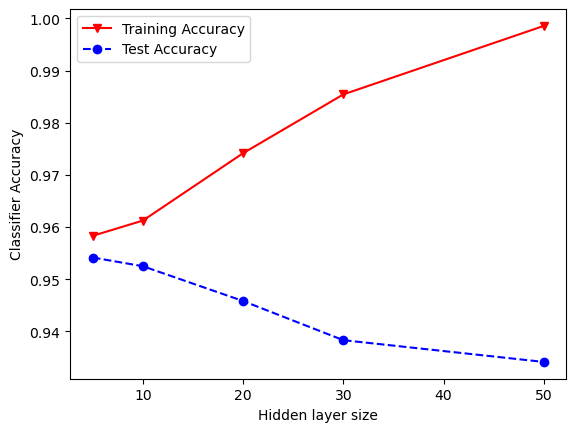

In [10]:
# Tune hidden layer size 
size_list = [5, 10, 20, 30, 50]
ann_train_accuracy = []
ann_test_accuracy = []
for s in size_list:
    ann = MLPClassifier(hidden_layer_sizes = (s,),
                    activation = "relu",
                    solver = "adam",
                    max_iter = 1000,
                    random_state = 11)
    ann.fit(X_train_scaled, Y_train)
    ann_train_predict = ann.predict(X_train_scaled)
    ann_test_predict = ann.predict(X_test_scaled)
    ann_accuracy_train = accuracy_score(Y_train, ann_train_predict)
    ann_accuracy_test = accuracy_score(Y_test, ann_test_predict)
    ann_train_accuracy.append(ann_accuracy_train)
    ann_test_accuracy.append(ann_accuracy_test)

# Plot of training and test accuracies vs hidden layer size  
plt.plot(size_list, ann_train_accuracy,'rv-', 
         size_list, ann_test_accuracy,'bo--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Hidden layer size')
plt.ylabel('Classifier Accuracy')
plt.show()

************** Artificial Neural Network **************

              precision    recall  f1-score   support

    Low Risk       0.97      0.97      0.97       520
 Prediabetes       0.90      0.86      0.88       231
   High Risk       0.97      0.98      0.97       449

    accuracy                           0.95      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.95      0.95      0.95      1200



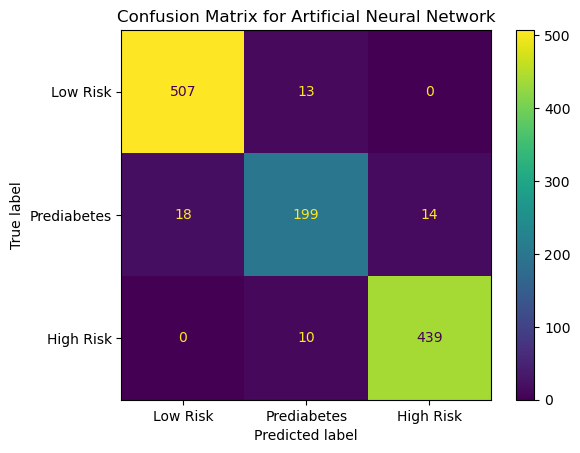

                       Feature  Importance
15      waist_circumference_cm    0.251333
4        fasting_glucose_level    0.248667
2                          bmi    0.165750
0                          age    0.071917
14     family_history_diabetes    0.047833
1                       gender    0.042083
9      physical_activity_level    0.028000
10        daily_calorie_intake    0.003667
6                  HbA1c_level    0.003083
8          triglycerides_level    0.003000
12                 sleep_hours    0.002500
13                stress_level    0.002083
3               blood_pressure    0.001667
11  sugar_intake_grams_per_day    0.001333
7            cholesterol_level    0.001250
5                insulin_level    0.000750


In [11]:
ann = MLPClassifier(hidden_layer_sizes = (5,),
                    activation = "relu",
                    solver = "adam",
                    max_iter = 1000,
                    random_state = 11)
# Train the neural network
ann.fit(X_train_scaled, Y_train)

# Predict test data
ann_test_predict = ann.predict(X_test_scaled)

# Classification metrics
print("************** Artificial Neural Network **************\n")
print(classification_report(Y_test, ann_test_predict,
      target_names=["Low Risk", "Prediabetes", "High Risk"]))

# Create and display confusion matrix
matrix_ann = confusion_matrix(Y_test, ann_test_predict)
display_ann = ConfusionMatrixDisplay(confusion_matrix = matrix_ann,
          display_labels = ["Low Risk", "Prediabetes", "High Risk"])
display_ann.plot()
plt.title("Confusion Matrix for Artificial Neural Network")
plt.show()

# Analysis using permutation feature importance
result = permutation_importance(ann, X_test_scaled, Y_test, 
    n_repeats = 10, random_state = 11, scoring = "accuracy")
importance_ann = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)
print(importance_ann)

The ANN model achieved the highest overall accuracy of 95% on the test set. It performed consistently well across all categories, with F1-scores of 0.97 for Low Risk, 0.88 for Prediabetes, and 0.97 for High Risk. Permutation feature importance showed that waist_circumference_cm and fasting_glucose_level were the most influential features, followed by bmi and age.

### **Model Comparison**

The Artificial Neural Network (ANN) and Support Vector Machine (SVM) achieved the highest performance, with accuracies of 95% and 94%, respectively. Both models performed consistently well across all risk categories. In contrast, the Naive Bayes model achieved the lowest performance (84% accuracy), particularly struggling with the Prediabetes class. This is likely due to its assumption of feature independence, which is unrealistic for correlated health variables such as BMI and waist circumference.

Across all models, BMI, waist circumference, and fasting glucose level were consistently identified as the most important predictors of diabetes risk. The Prediabetes category was the most difficult to classify for all models, likely due to overlapping feature values between risk groups.

### **Conclusion**

This analysis demonstrates that models such as Artificial Neural Networks and Support Vector Machines are highly effective for predicting diabetes risk. However, intermediate risk categories remain challenging due to overlapping characteristics. These findings show the importance of model selection and feature relevance in healthcare prediction tasks.